In [ ]:
# ONLY RUN THIS BLOCK IF TRAINING ON AMD RADEON RX 6750 XT, OTHERWISE SKIP

import os
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"
import torch

print("ROCm/HIP framework active?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Detected GPU:", torch.cuda.get_device_name(0))

ROCm/HIP framework active? True
Detected GPU: AMD Radeon RX 6750 XT


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from PIL import Image

# HuggingFace library for fetching the dataset
from datasets import load_dataset, concatenate_datasets
# For seeing progress while training / evaluating
from tqdm.auto import tqdm
# Hide warnings
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.accelerator as accel
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_iou
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead

from sklearn.metrics import ConfusionMatrixDisplay

!pip install torchmetrics
# For the evaluation phase
from torchmetrics.detection.mean_ap import MeanAveragePrecision

/home/ofir/Documents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
DATASET_FRACTION = 1
load_percent = int(DATASET_FRACTION * 100)

# Credits to https://huggingface.co/datasets/pathikg/drone-detection-dataset for the dataset
train_dataset = load_dataset("pathikg/drone-detection-dataset", split=f"train[:{load_percent}%]")
test_data  = load_dataset("pathikg/drone-detection-dataset", split="test")

def apply_columns(sample):
    img = sample["image"].convert("RGB").resize((640, 480), Image.BILINEAR)
    return {
        "width": img.width,
        "height": img.height,
        "objects": {
            "bbox": [],
            "category": [],
            "area": [],
            "id": []
        },
        "image": img,
        "image_id": -1
    }

aircraft_dataset = load_dataset("Voxel51/FGVC-Aircraft", split="train")
aircraft_dataset = aircraft_dataset.map(
    apply_columns,
    remove_columns=aircraft_dataset.column_names,
    features=train_dataset.features,
    batch_size=16,
    writer_batch_size=64,
    num_proc=2)

bird_dataset = load_dataset("cassiekang/cub200_dataset", split="train")
bird_dataset = bird_dataset.map(
    apply_columns,
    remove_columns=bird_dataset.column_names,
    features=train_dataset.features,
    batch_size=16,
    writer_batch_size=64,
    num_proc=2)

train_dataset = concatenate_datasets([train_dataset, aircraft_dataset, bird_dataset]).shuffle(seed=42)

In [ ]:
# Perform work on an accelerator if available
device = accel.current_accelerator() if accel.is_available() else "cpu"
print(device)

cuda


# Exploratory data analysis (EDA):

In [ ]:
print(f"There are {train_dataset.num_rows} train / validation samples")
print(f"There are {test_data.num_rows} test samples")

There are 67441 train / validation samples
There are 2625 test samples


Here we are taking a look at the data the dataset provides to get a sense of what we are working with.

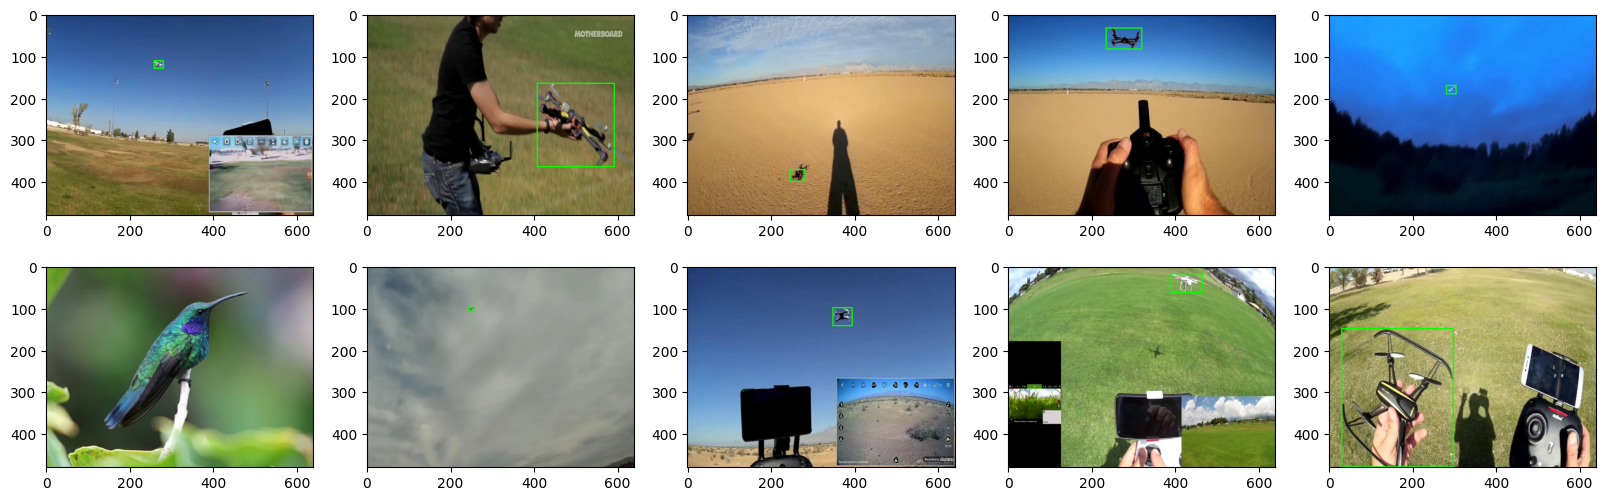

In [ ]:
# Create transform for displaying the images
eda_transform = v2.Compose([
    v2.ToTensor()
])

idx = rnd.randint(0, train_dataset.shape[0] - 11) # Show different images every execution
figs, axes = plt.subplots(2, 5, figsize=(20, 6))
for fig, ax in enumerate(axes.flat):
    # Transform the image to a tensor so draw_bounding_boxes can work with it.
    # Also convert bbox to a tensor and convert it to the correct format.
    transformed_image = eda_transform(train_dataset[fig + idx]["image"])

    bbox_tensor = torch.tensor(train_dataset[fig + idx]["objects"]["bbox"], dtype=torch.float32).reshape(-1, 4)

    # Format conversion
    bbox_converted = torchvision.ops.box_convert(
        bbox_tensor,
        in_fmt="xywh", # Images come in [x, y, width, height] format
        out_fmt="xyxy" # convert them to [x1, y1, x2, y2]
    )

    # Draw the ground-truth bounding boxes
    boxed_image = draw_bounding_boxes(
        transformed_image,
        bbox_converted,
        colors="#07ff00",
        width=3
    ).permute(1, 2, 0).numpy() # Reorder from (C, H, W) to (H, W, C)

    ax.imshow(boxed_image)

We can see that the images vary, so we can be somewhat confident that the network will learn to identify drones of different shapes and sizes in different scenarios (environments and lighting conditions).

The annotations are only for drones so there is no class imbalance that needs to be dealt with, we only need to take care of images with no drones (just background).

# Data splitting and preprocessing:

Since the dataset only provides train and test splits we have to take a chunk of the training data to be used for validation in the training loop:

In [ ]:
VAL_FROM_TRAIN = 0.05

# Take a chunk of the training data to be used for validation
val_size = int(VAL_FROM_TRAIN * train_dataset.num_rows)
train_size = train_dataset.num_rows - val_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

print(f"There are {len(train_data)} train samples")
print(f"There are {len(val_data)} validation samples")
print(f"There are {len(test_data)} test samples")

There are 64069 train samples
There are 3372 validation samples
There are 2625 test samples


Now we create the transformations we wish to be applied to the train, validation and test data (train will have more transformations as we wish for the network to generalize and validation and test data come as is).

As the data includes bounding boxes we use v2 (which takes bounding boxes into account when transformations are applied).

In [ ]:
# https://docs.pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_getting_started.html#videos-boxes-masks-keypoints

train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomZoomOut(fill=0, side_range=(1.0, 1.5), p=0.3),
    v2.ColorJitter(brightness=0.3, contrast=0.35, saturation=0.35, hue=0.1),
    v2.RandomGrayscale(p=0.1),
    v2.ToTensor(),
    v2.GaussianNoise(sigma=0.04),
])

val_transform = v2.Compose([
    v2.ToTensor(),
])

Normally we would also normalize with ImageNet statistics:

$$
    \mu = [0.485, 0.456, 0.406] \\
    \sigma = [0.229, 0.224, 0.225]
$$

but it is unnecessary as Faster R-CNN already normalizes internally.

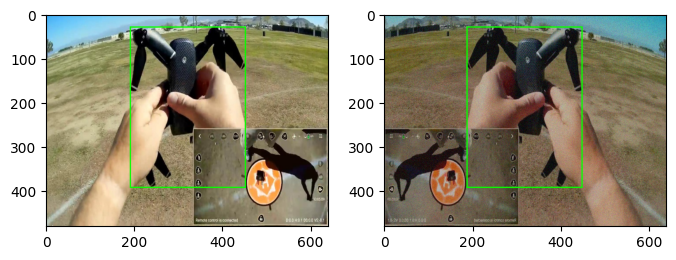

In [ ]:
# Check the transformations are working properly
# Compare the transformed image to the original image

idx = rnd.randint(0, len(train_data) - 1)
img = train_data[idx]["image"]

raw = train_data[idx]["objects"]["bbox"]
# Apply transformations while considering the bounding boxes
boxes = tv_tensors.BoundingBoxes(
    raw if len(raw) > 0 else torch.zeros((0, 4), dtype=torch.float32),
    format="XYWH",
    canvas_size=(img.height, img.width)
)
transformed_img = train_transform(img, boxes)

fig, ax = plt.subplots(1, 2, figsize=((8, 4)))

# Show original image
bbox_tensor = torch.tensor(train_data[idx]["objects"]["bbox"], dtype=torch.float32).reshape(-1, 4)
bbox_converted = torchvision.ops.box_convert(
    bbox_tensor,
    in_fmt="xywh",
    out_fmt="xyxy"
)

boxed_image = draw_bounding_boxes(
    eda_transform(img),
    bbox_converted,
    colors="#07ff00",
    width=3
).permute(1, 2, 0).numpy()
ax[0].imshow(boxed_image)

# Show transformed image
bbox_tensor = torch.tensor(transformed_img[1], dtype=torch.float32)
bbox_converted = torchvision.ops.box_convert(
    bbox_tensor,
    in_fmt="xywh",
    out_fmt="xyxy"
)

boxed_image = draw_bounding_boxes(
    transformed_img[0],
    bbox_converted,
    colors="#07ff00",
    width=3
).permute(1, 2, 0).numpy()
ax[1].imshow(boxed_image)

# Dataset and DataLoaders

In [ ]:
class DroneDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform

    # Get the length of the dataset
    def __len__(self):
        return len(self.data)

    # Get a single sample from the dataset
    def __getitem__(self, idx):
        sample = self.data[idx]
        img = sample['image']
        bbox_sample=sample['objects']['bbox'] if "objects" in sample else []

        # Image has no annotated drones (no bounding boxes)
        if (len(bbox_sample)) == 0:
            boxes = tv_tensors.BoundingBoxes(
                torch.zeros((0, 4), dtype=torch.float32),
                format="XYWH",
                canvas_size=(img.height, img.width)
            )
        else:
            boxes = tv_tensors.BoundingBoxes(
                bbox_sample,
                format="XYWH",
                canvas_size=(img.height, img.width)
            )

        img, boxes = self.transform(img, boxes)

        bbox_converted = torchvision.ops.box_convert(
            boxes.clone().detach().to(torch.float32),
            in_fmt='xywh',
            out_fmt='xyxy'
        )
        target = {
            'boxes': bbox_converted,
            'labels': torch.ones(len(bbox_converted), dtype=torch.int64)
        }

        # Faster R-CNN expects the input to be of the format [list of images, list of targets (dictionaries)] where
        # target is a dictionary with a list of all bounding boxes and all labels (where all are 1 because only drones
        # are being detected, everything else is background).
        return img, target

train_set = DroneDataset(train_data, train_transform)
val_set = DroneDataset(val_data, val_transform)
test_set = DroneDataset(test_data, val_transform)

We are getting tensors of different lengths for the "boxes" list in "target" (returned from __getitem__) because some images have more than one bounding box. Tensors of different lengths cannot be stacked together (which is what DataLoader does when pulling data in batches).

collate_fn() tells the DataLoader how to organize the data instead of stacking it.

In [ ]:
def collate_fn(batch):
    # Match the Faster R-CNN format.
    # Go from [[img_1, target_1], ..., [img_n, target_n]] ```to ([img_1, img_2, ...], [target_1, target_2, ...]).
    return tuple(zip(*batch))

BATCH_SIZE = 4

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle so the network doesn't overfit on the order of items
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

# train_loader sanity check:
images, targets = next(iter(train_loader))
print(f"Number of images in batch: {len(images)}")
print(f"Target dictionary keys: {targets[0].keys()}")
print(f"First image boxes shape: {targets[0]["boxes"].shape}")

Number of images in batch: 4
Target dictionary keys: dict_keys(['boxes', 'labels'])
First image boxes shape: torch.Size([1, 4])


# Pre-trained Faster R-CNN model and fine-tuning

Even though it is slower than other models, we will be using Faster R-CNN as it is more accurate. As many countries are facing dangers from drones in the last few years, we want the model to be able to identify drones accurately.

We need to replace the pre-trained model's head so we observe its structure and make the necessary changes.

In [ ]:
# Load pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

for name, child in model.named_children():
    print(name, child)

transform GeneralizedRCNNTransform(
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    Resize(min_size=(800,), max_size=1333, mode='bilinear')
)
backbone BackboneWithFPN(
  (body): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): FrozenBatchNorm2d(64, eps=0.0)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): FrozenBatchNorm2d(64, eps=0.0)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): FrozenBatchNorm2d(64, eps=0.0)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): FrozenBatchNorm2d(256, eps=0.0)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

In [ ]:
# Replace the classifier head for 2 classes (drone or background)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)

model.transform.min_size = (480,)
model.transform.max_size = 640

# Default anchors start at 32px which is too large for small drones (can be 10-20px).
model.rpn.anchor_generator = AnchorGenerator(
    sizes=((8, 16), (16, 32), (32, 64), (64, 128), (128, 256)),
    aspect_ratios=((0.5, 1.0, 2.0),) * 5
)

# Replace the RPNHead to match the new anchors-per-location count.
num_anchors_per_loc = model.rpn.anchor_generator.num_anchors_per_location()[0]
model.rpn.head = RPNHead(model.backbone.out_channels, num_anchors_per_loc)

# Reprint the new head to see the changes
print(model.roi_heads.box_predictor)
print(model.rpn.anchor_generator)

# Move model to the GPU to accelerate training and inference
_ = model.to(device)

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)
AnchorGenerator()


As we are doing "transfer learning", the existing model was already pre-trained to identify some patterns / textures / shapes / etc.

We freeze most of the model and unfreeze some of the later layers.

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.backbone.body.layer4.parameters():
    param.requires_grad = True
for param in model.backbone.fpn.parameters():
    param.requires_grad = True
for param in model.rpn.parameters():
    param.requires_grad = True
for param in model.roi_heads.parameters():
    param.requires_grad = True

# Training and validation

In [ ]:
optimizer = torch.optim.AdamW(
    [
        {"params": model.backbone.body.layer4.parameters()},
        {"params": model.backbone.fpn.parameters()},
        {"params": model.rpn.parameters()},
        # New head is task specific, we can train it more aggressively
        {"params": model.roi_heads.parameters(), "lr": 5e-5}
    ],
    lr=5e-6,
    weight_decay=5e-4
)

# Cut the learning rate if the model isn't improving
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max", # Maximize mAP50-95
    factor=0.5,
    patience=3, # If mAP50-95 hasn't improved for 3 epochs
    threshold=1e-3, # Ignore noise
    threshold_mode="abs",
    min_lr=1e-7
)

LINEAR_WARMUP_EPOCHS = 5
# Linear warmup for a slow start when the network has noisy weights (the head)
scheduler_linear = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.01, # Multiply the optimizer's learning rate by this
    end_factor=1.0, # Move towards the optimizer's original learning rate
    total_iters=LINEAR_WARMUP_EPOCHS # Changes over 5 epochs (stepped once per epoch)
)

Other than training loss we also track validation loss to see if the model underfits / overfits. Faster R-CNN does not provide loss values during eval() so we run the validation forward pass in train() mode without gradients to get them.

On top of the losses we track validation mAP as a measure for how accurate the model's predicted bounding boxes (IoU) are on unseen data, and mAR100 as the model's recall ceiling (the fraction of drones it would find if every detection was accepted).

The best model is selected by mAP50-95 (mAP averaged over IoU 0.5 to 0.95) rather than mAP50: mAP50 saturates early while box localization keeps improving, and tighter boxes are what lift the test scores. We should see the validation metrics increasing as the losses decrease over epochs.

In [ ]:
NUM_EPOCHS = 50
# Roughly double the plateau scheduler's patience (3) so a learning rate cut gets
# a few epochs to show improvement before training is stopped
EARLY_STOPPING_PATIENCE = 7

# Track stats for plotting later
stats = {
    "train_loss": [],
    "val_loss": [],
    "val_map_50": [],
    "val_map_75": [],
    "val_map": [],
    "val_mar_100": [],
    "lr_back": [],
    "lr_head": []
}

# https://docs.pytorch.org/docs/2.12/amp.html
# https://docs.pytorch.org/docs/2.12/notes/amp_examples.html#working-with-scaled-gradients
scaler = torch.amp.GradScaler("cuda")

# https://torchmetrics.readthedocs.io/en/v0.8.2/detection/mean_average_precision.html
map_metric = MeanAveragePrecision().to(device)

# Training loop - https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html
best_val_map = 0
epochs_no_improve = 0
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [TRAINING]", leave=True)

    #####################
    ### TRAINING MODE ###
    #####################
    # Need to track gradients
    for images, targets in train_pbar:
        X = [img.to(device) for img in images]
        y = [{box: label.to(device) for box, label in target.items()} for target in targets]

        # Properly scale float32 to float16, halving memory and time requirements
        with torch.amp.autocast("cuda"):
            train_loss_dict = model(X, y)
            train_losses = sum(loss for loss in train_loss_dict.values())

        optimizer.zero_grad()
        scaler.scale(train_losses).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += train_losses.item()
        train_pbar.set_postfix(loss=f"{train_losses.item():.3f}")

    # Average train loss over the entire training set for the current epoch
    avg_train_loss = train_loss / len(train_loader)

    #######################
    ### VALIDATION MODE ###
    #######################
    # Faster R-CNN does not return losses in eval() mode, so we run a forward pass in
    # train() mode without gradients. This is safe because the backbone's BatchNorm
    # layers are FrozenBatchNorm2d (frozen statistics), so train() mode does not
    # change their behavior.
    model.train()
    val_loss = 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [VALIDATION]  ", leave=True)
    with torch.no_grad():
        for images, targets in val_pbar:
            X = [img.to(device) for img in images]
            y = [{box: label.to(device) for box, label in target.items()} for target in targets]

            val_loss_dict = model(X, y)
            val_losses = sum(loss for loss in val_loss_dict.values())

            val_loss += val_losses.item()

    # Average validation loss over the entire validation set for the current epoch
    avg_val_loss = val_loss / len(val_loader)

    val_map_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [mAP]  ", leave=True)
    model.eval()
    # Model in evaluation mode, no need to track gradients
    with torch.no_grad():
        for images, targets in val_map_pbar:
            X = [img.to(device) for img in images]
            y = [{box: label.to(device) for box, label in target.items()} for target in targets]

            y_pred = model(X)
            map_metric.update(y_pred, y)

    # Compute mAP over the entire validation set
    mAP_results = map_metric.compute()
    # Resetting the metric state for the next epoch
    map_metric.reset()
    val_map_50 = mAP_results["map_50"].item()
    val_map_75 = mAP_results["map_75"].item()
    # Average over IoU 0.5 to 0.95
    val_map = mAP_results["map"].item()
    # Recall ceiling: the fraction of drones that would be found if up to 100
    # detections per image were accepted (threshold-free). If this plateaus, no
    # confidence threshold tuning can raise recall past it
    val_mar_100 = mAP_results["mar_100"].item()

    # Update schedulers
    if epoch <= LINEAR_WARMUP_EPOCHS: # LinearLR warms up for the first LINEAR_WARMUP_EPOCHS epochs, after that ReduceLROnPlateau takes effect
        scheduler_linear.step()
    else:
        scheduler_plateau.step(val_map)

    ###################
    ### LOG CHANGES ###
    ###################
    current_lr_back = optimizer.param_groups[0]["lr"]
    current_lr_head = optimizer.param_groups[3]["lr"]

    print(f"Average training loss: {avg_train_loss:.3f}")
    print(f"Average validation loss: {avg_val_loss:.3f}")
    print(f"mAP (averaged IoU 0.5 to 0.95): {val_map:.3f}")
    print(f"Validation mAR100 (recall ceiling): {val_mar_100:.3f}")
    print(f"Learning rate (back): {current_lr_back:.7f}, Learning rate (head): {current_lr_head:.7f}")

    stats["train_loss"].append(avg_train_loss)
    stats["val_loss"].append(avg_val_loss)
    stats["val_map_50"].append(val_map_50)
    stats["val_map_75"].append(val_map_75)
    stats["val_map"].append(val_map)
    stats["val_mar_100"].append(val_mar_100)
    stats["lr_back"].append(current_lr_back)
    stats["lr_head"].append(current_lr_head)

    # Select on mAP50-95
    if val_map > best_val_map:
        best_val_map = val_map
        epochs_no_improve = 0
        torch.save(model.state_dict(), "drone_detection_model_best.pth")
        print(f"---> New best mAP50-95 {val_map:.3f}, model saved")
    else:
        epochs_no_improve += 1
        print(f"---> No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered")
            break

Epoch 1/50 [mAP]  : 100%|██████████████████████████████████| 843/843 [01:43<00:00,  8.12it/s]


Average training loss: 0.276
Average validation loss: 0.059
mAP (averaged IoU 0.5 to 0.95): 0.264
Validation mAR100 (recall ceiling): 0.346
Learning rate (back): 0.0000010, Learning rate (head): 0.0000104
---> New best mAP50-95 0.264, model saved


Epoch 2/50 [mAP]  : 100%|██████████████████████████████████| 843/843 [01:24<00:00, 10.00it/s]


Average training loss: 0.052
Average validation loss: 0.052
mAP (averaged IoU 0.5 to 0.95): 0.638
Validation mAR100 (recall ceiling): 0.698
Learning rate (back): 0.0000020, Learning rate (head): 0.0000203
---> New best mAP50-95 0.638, model saved


Epoch 3/50 [mAP]  : 100%|██████████████████████████████████| 843/843 [01:25<00:00,  9.86it/s]


...

Average training loss: 0.029
Average validation loss: 0.036
mAP (averaged IoU 0.5 to 0.95): 0.739
Validation mAR100 (recall ceiling): 0.777
Learning rate (back): 0.0000003, Learning rate (head): 0.0000031
---> No improvement for 5/7 epochs


Epoch 43/50 [mAP]  : 100%|█████████████████████████████████| 843/843 [01:28<00:00,  9.49it/s]


Average training loss: 0.029
Average validation loss: 0.036
mAP (averaged IoU 0.5 to 0.95): 0.737
Validation mAR100 (recall ceiling): 0.775
Learning rate (back): 0.0000003, Learning rate (head): 0.0000031
---> No improvement for 6/7 epochs


Epoch 44/50 [mAP]  : 100%|█████████████████████████████████| 843/843 [01:09<00:00, 12.11it/s]


Average training loss: 0.029
Average validation loss: 0.036
mAP (averaged IoU 0.5 to 0.95): 0.737
Validation mAR100 (recall ceiling): 0.776
Learning rate (back): 0.0000003, Learning rate (head): 0.0000031
---> No improvement for 7/7 epochs
Early stopping triggered


# Model evaluation


First we observe the values measured during training to see how the model has changed over time.

In [ ]:
# Load the best checkpoint saved during training
model.load_state_dict(torch.load("drone_detection_model_best.pth", map_location=device))
model.to(device)
model.eval()
# best_val_map only exists if the training loop ran in this session
if "best_val_map" in globals():
    print(f"Best model loaded (best val mAP50-95: {best_val_map:.3f})")
else:
    print("Best model loaded")

Best model loaded (best val mAP50-95: 0.743)


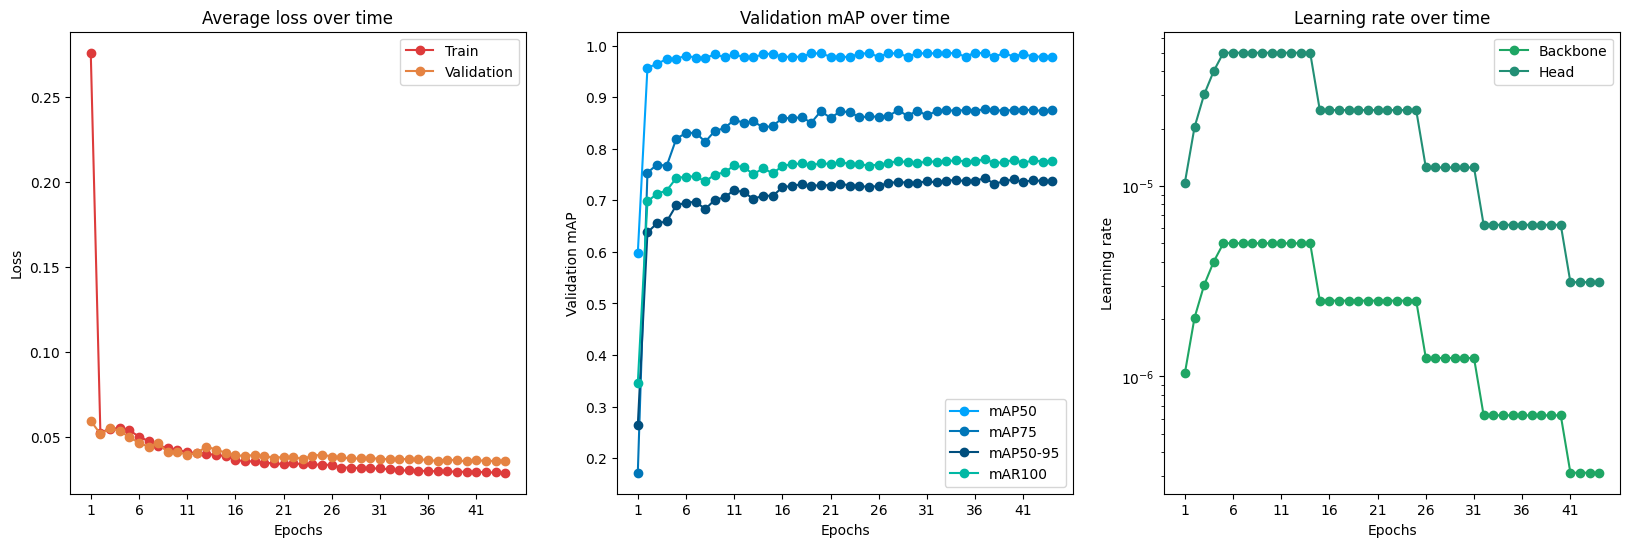

In [ ]:
epochs = np.arange(1, len(stats["train_loss"]) + 1)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
def plot_stats(idx, stat, color, ylabel, title, log=False, label=None):
    '''
    Plot graphs to see how the model performed over time and with different learning
    rates (if scheduler changed learning rate at all)
    '''
    if log == False:
        ax[idx].plot(epochs, stats[stat], "o-", color=color, label=label)
    else:
        ax[idx].semilogy(epochs, stats[stat], "o-", color=color, label=label)
    ax[idx].set_xticks(np.arange(1, len(epochs) + 1, 5))
    ax[idx].set_xlabel("Epochs")
    ax[idx].set_ylabel(ylabel)
    ax[idx].set_title(title)
    if label is not None:
        ax[idx].legend()

# Plot training loss, validation mAP score and learning rate (if changed at all) over epochs
plot_stats(0, "train_loss", "#DD3B3B", "Loss", "Average loss over time", label="Train")
plot_stats(0, "val_loss", "#E58342", "Loss", "Average loss over time", label="Validation")
plot_stats(1, "val_map_50", "#00A4FC", "Validation mAP", "Validation mAP over time", label="mAP50")
plot_stats(1, "val_map_75", "#0076B8", "Validation mAP", "Validation mAP over time", label="mAP75")
plot_stats(1, "val_map", "#004E7D", "Validation mAP", "Validation mAP over time", label="mAP50-95")
plot_stats(1, "val_mar_100", "#00B8A4", "Validation mAP", "Validation mAP over time", label="mAR100")
plot_stats(2, "lr_back", "#1EA664", "Learning rate", "Learning rate over time", True, label="Backbone")
plot_stats(2, "lr_head", "#228F75", "Learning rate", "Learning rate over time", True, label="Head")

Then we test the model using the test set which it has not yet seen.

With the results we get we will:
1. See how it scored using different scoring methods.
2. Observe its confusion matrix to get a better numerical sense of how it performed.
3. Get a look of some visual examples of if it was able to detect drones and where (how well the bounding box placement is compared to the ground truth).

In [ ]:
# A prediction counts as a hit if it overlaps a ground-truth box by at least this
# IoU. 0.3 rather than the conventional 0.5 because the application only needs
# rough localization: the box has to point at the drone, not fit it tightly.
MATCH_IOU = 0.3

def img_iou(pred_boxes, truth_boxes, match_iou=MATCH_IOU):
    '''
    Count the number of TP, FP and FN in an image to be used for calculating scores
    (precision, recall and F2) and for displaying a confusion matrix.
    A prediction matches a ground-truth box if their IoU is at least match_iou.
    Everything else is background and TN so we don't count that.
    '''
    true_positive = 0
    false_positive = 0
    false_negative = 0

    # No drones in the picture, nothing to count
    if len(pred_boxes) == 0 and len(truth_boxes) == 0:
        return true_positive, false_positive, false_negative
    # Model missed all the drones in the image
    if len(pred_boxes) == 0:
        false_negative = len(truth_boxes) # All missed drones considered background
        return true_positive, false_positive, false_negative
    # Predicted but no drone exists in the picture
    if len(truth_boxes) == 0:
        false_positive = len(pred_boxes) # Background was considered to be a drone
        return true_positive, false_positive, false_negative

    # For the boxes passed, we get a matrix where the number of columns is the number
    # of ground-truth boxes in the image and the number of rows it the number of boxes
    # the model predicted, each cell (i, j) is the IoU score of the i-th predicted box
    # and the j-th ground-truth box
    # https://docs.pytorch.org/vision/main/generated/torchvision.ops.box_iou.html
    iou_mat = box_iou(pred_boxes, truth_boxes)
    boxes_used = []
    for row in range(len(pred_boxes)):
        # Only consider ground-truth boxes that were not matched yet, so a prediction
        # is not counted as a false positive just because its best overlap was already
        # taken while another (still free) ground-truth box also overlaps it enough
        iou_row = iou_mat[row].clone()
        iou_row[boxes_used] = -1
        max_iou, max_iou_idx = iou_row.max(dim=0)
        max_iou_idx = max_iou_idx.item()

        if max_iou >= match_iou:
            true_positive += 1
            # Once a ground-truth box is matched it can no longer be used because the
            # drone it represents was already "detected" and there is no point in
            # detecting it again with a different box, so any further box on the same
            # drone counts as a false positive
            boxes_used.append(max_iou_idx)
        else:
            false_positive += 1

    # Any drone not captured is FN because it was considered background, incorrectly
    # classifying a positive sample as negative
    false_negative = len(truth_boxes) - len(boxes_used)

    return true_positive, false_positive, false_negative

NMS already removes most duplicate boxes, but two predictions can still land on the same drone. So `img_iou` matches each ground-truth box only once: the first prediction to match it is a **true positive**; a later one whose only sufficient overlap is with an already-matched drone is a **false positive** (a duplicate is a false alarm, not a second hit). Unmatched ground-truth boxes are false negatives.

A prediction matches if IoU $\ge$ MATCH_IOU = 0.3 — lower than the usual 0.5 because we only need rough localization: the box must point at the drone, not fit it tightly.

Example: 2 ground-truth boxes, 3 predictions, giving this 3x2 IoU matrix (made-up values):

$$
    \begin{pmatrix}
        0.79 & 0.34 \\
        0.67 & 0.13 \\
        0.25 & 0.88
    \end{pmatrix}
$$

- Row 1: best free match is column 1 (0.79 $\ge$ 0.3) → **TP**, column 1 taken.
- Row 2: column 1 is taken and no free column reaches 0.3 → **FP**.
- Row 3: column 2 (0.88 $\ge$ 0.3) is still free → **TP**.

Result: 2 TP, 1 FP, 0 FN.

For calculating scores (recall, precision and F2) and displaying the confusion matrix we first need to count how many TP, FP, FN there are.

## Threshold scan

We don't guess a confidence threshold. We try 0.05–0.99 in steps of 0.01 on the **validation** set and keep the best one, leaving the test set for the final, unbiased evaluation.

"Best" means highest F2 — F-beta with $\beta = 2$, which weights recall four times as heavily as precision. A missed drone (FN) is worse than a false alarm (FP), so we lean towards catching drones.

Every candidate runs the same pipeline as the test loop — score filter, NMS at IoU 0.5, then `img_iou` counting — so the scan matches the final evaluation.

In [ ]:
# Collect the model's predictions on the validation set once so we can sweep
# thresholds without re-running it
image_predictions = []

model.eval()
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="[COLLECTING PREDICTIONS]"):
        X = [img.to(device) for img in images]

        y_pred = model(X)
        for prediction, target in zip(y_pred, targets):
            image_predictions.append({
                "boxes": prediction["boxes"].cpu(),
                "scores": prediction["scores"].cpu(),
                "truth_boxes": target["boxes"],
            })

# The confidence thresholds to scan through
candidate_thresholds = np.arange(0.05, 1.0, 0.01)

# A missed drone is worse than a false alarm, so we weight recall above precision when
# picking the threshold. F-beta with beta=2 does that (recall counts 4x as much as
# precision); raise BETA to lean even harder on recall.
BETA = 2

# Track the best threshold and the scores it produced
best_fbeta = 0
best_threshold = 0
best_precision = 0
best_recall = 0
best_f1 = 0

# For the PR curve
precisions = []
recalls = []
thresholds = []

# Go through each threshold and keep the one that gives the best F-beta score
for threshold in tqdm(candidate_thresholds, desc="[THRESHOLD SCAN]"):
    true_positive_total = 0
    false_positive_total = 0
    false_negative_total = 0

    for prediction in image_predictions:
        scores = prediction["scores"]
        boxes = prediction["boxes"]
        truth_boxes = prediction["truth_boxes"]

        # Score threshold
        keep_score = scores >= threshold
        boxes = boxes[keep_score]
        scores = scores[keep_score]

        # NMS to remove redundant overlapping boxes for the same drone (same as the
        # test loop). Boxes are considered "for the same drone" if the overlap is
        # greater than 0.5
        if len(boxes) > 0:
            keep_nms = torchvision.ops.nms(boxes, scores, iou_threshold=0.5)
            pred_boxes = boxes[keep_nms]
        else:
            pred_boxes = boxes

        # Get the TP, FP, FN count from a single image and update counters
        true_positive, false_positive, false_negative = img_iou(pred_boxes, truth_boxes)
        true_positive_total += true_positive
        false_positive_total += false_positive
        false_negative_total += false_negative

    # Skip thresholds with no correct detections: precision / recall are 0 or
    # undefined so they can never be the best, and the divisions below would break
    if true_positive_total == 0:
        continue

    precision = true_positive_total / (true_positive_total + false_positive_total)
    recall = true_positive_total / (true_positive_total + false_negative_total)
    f1 = (2 * precision * recall) / (precision + recall)

    # F-beta weights recall above precision (beta=2), unlike F1 which weights them equally
    fbeta = ((1 + BETA**2) * precision * recall) / ((BETA**2 * precision) + recall)

    precisions.append(precision)
    recalls.append(recall)
    thresholds.append(threshold)

    # Keep this threshold if it beats the best F-beta score so far
    if fbeta > best_fbeta:
        best_fbeta = fbeta
        best_threshold = threshold
        best_precision = precision
        best_recall = recall
        best_f1 = f1

SCORE_THRESHOLD = float(best_threshold)

print(f"Best threshold: {SCORE_THRESHOLD:.3f} (selected by F{BETA})")
print(f"Best F{BETA}: {best_fbeta:.3f}  |  F1 at this threshold: {best_f1:.3f}")
print(f"Precision: {best_precision:.3f}")
print(f"Recall: {best_recall:.3f}")

[THRESHOLD SCAN]: 100%|██████████████████████████████████████| 95/95 [00:20<00:00,  4.56it/s]

Best threshold: 0.930 (selected by F2)
Best F2: 0.980  |  F1 at this threshold: 0.977
Precision: 0.972
Recall: 0.982


Text(0.5, 1.0, 'Validation PR curve')

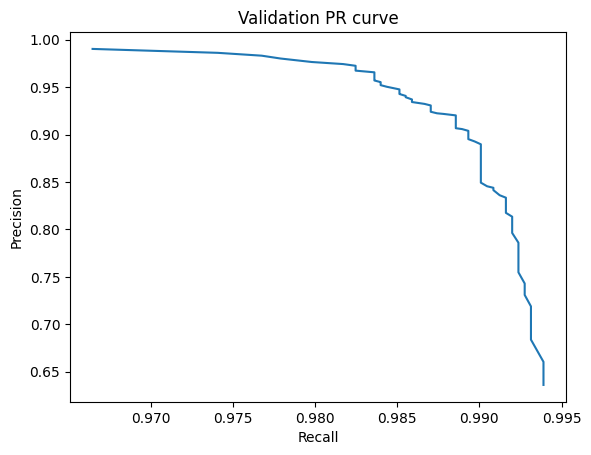

In [ ]:
precisions = np.array(precisions)
recalls = np.array(recalls)

plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation PR curve")

And now we use the best threshold we found to see how the model performs on the test set.

In [ ]:
test_pbar = tqdm(test_loader, desc="[TESTING]", leave=True)

true_positive_total = 0
false_positive_total = 0
false_negative_total = 0

model.eval()
with torch.no_grad():
    for images, targets in test_pbar:
        X = [img.to(device) for img in images]

        y_pred = model(X)
        for prediction, target in zip(y_pred, targets):
            scores = prediction["scores"].cpu()
            boxes = prediction["boxes"].cpu()

            # Score threshold
            keep_score = scores >= SCORE_THRESHOLD
            boxes = boxes[keep_score]
            scores = scores[keep_score]

            # NMS to remove redundant overlapping boxes for the same drone
            # Boxes are considered "for the same drone" if the overlap is
            # greater than 0.5
            if len(boxes) > 0:
                keep_nms = torchvision.ops.nms(boxes, scores, iou_threshold=0.5)
                pred_boxes = boxes[keep_nms]
            else:
                pred_boxes = boxes

            truth_boxes = target["boxes"]

            # Get the TP, FP, FN count from a single image and update counters
            true_positive, false_positive, false_negative = img_iou(pred_boxes, truth_boxes)
            true_positive_total += true_positive
            false_positive_total += false_positive
            false_negative_total += false_negative

print(f"TP: {true_positive_total}, FP: {false_positive_total}, FN: {false_negative_total}")

[TESTING]: 100%|███████████████████████████████████████████| 657/657 [01:00<00:00, 10.86it/s]

TP: 2538, FP: 131, FN: 325


Now that we have the counts we can calculate scores. We report F2 (F-beta with $\beta = 2$) rather than F1, matching the metric the threshold was selected on — recall is weighted more heavily because a missed drone is worse than a false alarm. Note that these are precision / recall at the relaxed IoU >= 0.3 matching criterion (rough localization), so they are not directly comparable to results reported at the conventional IoU 0.5.

$$
    precision = \frac{TP}{TP + FP} \qquad
    recall = \frac{TP}{TP + FN}
$$

$$
    F_\beta = (1 + \beta^2) \cdot \frac{precision \cdot recall}{\beta^2 \cdot precision + recall}
    \quad\Longrightarrow\quad
    F_2 = 5 \cdot \frac{precision \cdot recall}{4 \cdot precision + recall}
$$

In [ ]:
precision_score = true_positive_total / (true_positive_total + false_positive_total)
recall_score = true_positive_total / (true_positive_total + false_negative_total)
# F-beta with beta = 2 (same objective used for the threshold scan), weighting recall over precision
fbeta_score = (1 + BETA**2) * precision_score * recall_score / (BETA**2 * precision_score + recall_score)

pd.Series([precision_score, recall_score, fbeta_score], ["Precision", "Recall", f"F{BETA}"], name="Scores")

Precision    0.950918
Recall       0.886483
F2           0.898662
Name: Scores, dtype: float64

and plot a confusion matrix to view things in a nicer way.

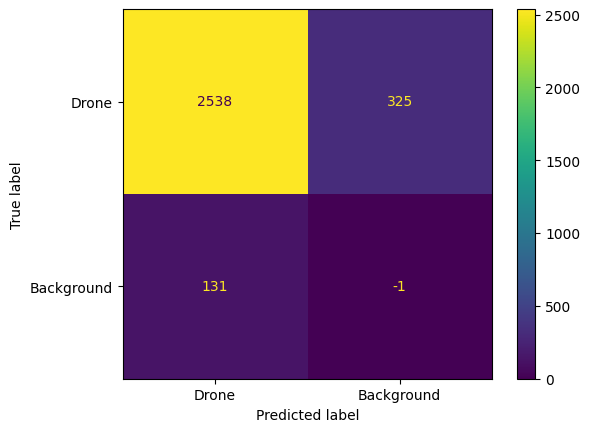

In [ ]:
counts = np.array([
    [true_positive_total, false_negative_total],
    [false_positive_total, -1] # Background marked as -1 because we care about drones
])

classes = np.array(["Drone", "Background"])

conf_mat = ConfusionMatrixDisplay(confusion_matrix=counts, display_labels=classes)
conf_mat.plot()

Now we will take a look at some examples with the test set to get a sense of how the model performs on previously unseen data.

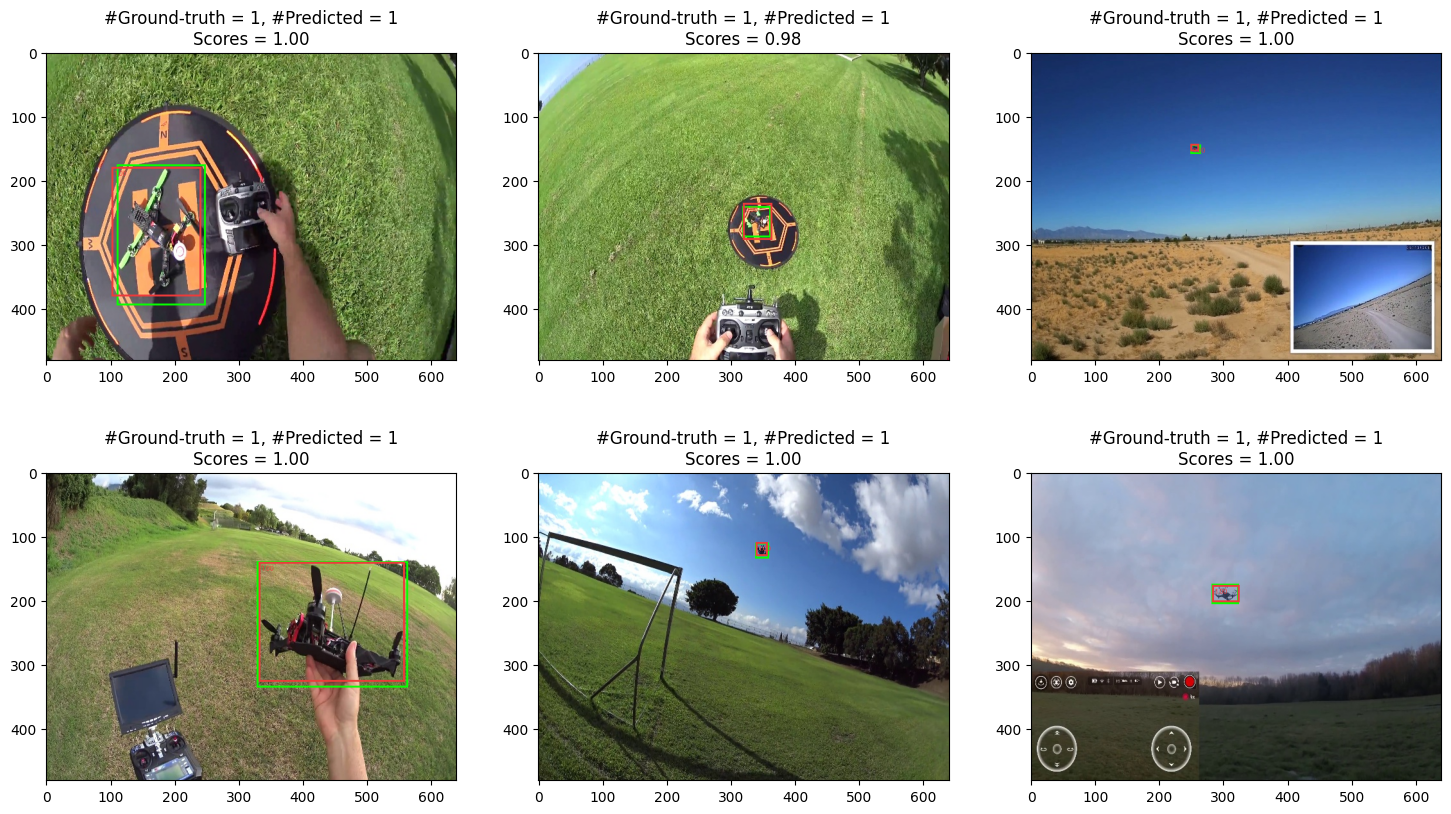

In [ ]:
idx = rnd.randint(0, test_data.shape[0] - 11) # Show different images every execution
figs, axes = plt.subplots(2, 3, figsize=(18, 10))

with torch.no_grad():
    for fig, ax in enumerate(axes.flat):
        # Transform the image to a tensor so draw_bounding_boxes can work with it.
        # Also convert bbox to a tensor and convert it to the correct format.
        transformed_image = val_transform(test_data[fig + idx]['image'])

        # Make predictions for a single image
        pred_i = model([transformed_image.to(device)])

        bbox_tensor = torch.tensor(test_data[fig + idx]['objects']['bbox'], dtype=torch.float32).reshape(-1, 4)

        # Format conversion
        bbox_converted = torchvision.ops.box_convert(
            bbox_tensor,
            in_fmt='xywh', # Images come in [x, y, width, height] format
            out_fmt='xyxy' # convert them to [x1, y1, x2, y2]
        )

        # Draw the ground-truth bounding boxes
        boxed_image = draw_bounding_boxes(
            transformed_image,
            bbox_converted,
            colors='#07ff00',
            width=3
        )

        # Score threshold (consistent with the test evaluation)
        keep_score = pred_i[0]["scores"] >= SCORE_THRESHOLD
        filtered_boxes = pred_i[0]["boxes"][keep_score]
        filtered_scores = pred_i[0]["scores"][keep_score]

        # NMS to remove redundant overlapping boxes for the same drone (consistent
        # with the test evaluation)
        if len(filtered_boxes) > 0:
            keep_nms = torchvision.ops.nms(filtered_boxes, filtered_scores, iou_threshold=0.5)
            filtered_boxes = filtered_boxes[keep_nms]
            filtered_scores = filtered_scores[keep_nms]

        # Draw the predicted bounding boxes
        boxed_image = draw_bounding_boxes(
            boxed_image,
            filtered_boxes,
            labels=[f"{score:.2f}" for score in filtered_scores],
            font_size=256,
            colors="#ed3b3b",
            width=3,
        ).permute(1, 2, 0).numpy() # Reorder from (C, H, W) to (H, W, C)

        scores_str = ', '.join(f'{score:.2f}' for score in filtered_scores)
        ax.imshow(boxed_image)
        ax.set_title(f"#Ground-truth = {bbox_converted.shape[0]}, #Predicted = {filtered_boxes.shape[0]}\nScores = {scores_str}")

We are getting fairly accurate bounding box placements, high precision and decent recall in various environments such as grassy fields, deserts, closed rooms, etc.

As for the future and continuation of this project it would be interesting the consider doing the following:
*   Instead of maximizing mAP50-95, minimize average validation loss (scheduler).
*   Train a more modern and / or lighter base model such as YOLOv11n (2024).
*   Bigger / Different dataset and higher resolution images with hardware that fits the task better which will allow us to train for longer and faster (For this project we couldn't train in Google Colab / Kaggle due to their time limitations so we had to train locally on our own hardware, in this case AMD GPUs and 16GB RAM, so training took a long time and wasn't always stable).
*   Differentiating between multiple categories (such as drones, birds, airplanes, helicopters) instead of strict drone detection.
*   Side-by-side comparison of results from different models.
*   Model pruning to see how lighter the model can be made without a large impact on performance.

